<a href="https://colab.research.google.com/github/zhuhanzhi6/Hanzhi-Zhu-machine-learning/blob/main/Lecture9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Research Challenge

<div style="background-color: #f8d7da; border-left: 6px solid #ccc; margin: 20px; padding: 15px;">
    <strong>💡 Margaret Atwood:</strong> Every aspect of human technology has a dark side, including the bow and arrow.
</div>

## 🏅 Build your own model

It is time to go back to supervised machine learning problems.

You have been assigned one dataset from [MatBench](https://matbench.materialsproject.org) as introduced in the [Lecture slides](https://speakerdeck.com/aronwalsh/mlformaterials-challenge-25). You are free to choose and tune any machine-learning model, with any Python library, but it should be appropriate for the problem. For instance, [XGBoost](https://xgboost.readthedocs.io) could be a good starting starting point to build a regression model. You can refer back to earlier notebooks and repurpose code as needed.

You may reach the limits of computing processing power on Google Colab. Building a useful model with limited resources is a real-world skill. Using other free resources is allowed if you find an alternative service, as is running on your own computer. A model tracker such as [wandb](https://wandb.ai) could be helpful for advanced users. If you want to try a brute force approach, a library such as [Automatminer](https://hackingmaterials.lbl.gov/automatminer) may be of interest.

This notebook should be used for keeping a record of your model development, submission, and even your presentation. You are free to edit (add/remove/delete) or rearrange the cells as you see fit.

### Your details

In [1]:
import numpy as np

# Insert your values
Name = "Hanzhi Zhu" # Replace with your name
CID = 2243276 # Replace with your College ID (as a numeric value with no leading 0s)

# Set a random seed using the CID value
CID = int(CID)
np.random.seed(CID)

# Print the message
print("This is the work of " + Name + " [CID: " + str(CID) + "]\n")

# Define the available groups
groups = ['A', 'B', 'C', 'D', 'E']

# Select a group based on the seeded random state
challenge_group = np.random.choice(groups)

# Print the challenge code
print("Your challenge code is " + challenge_group)

This is the work of Hanzhi Zhu [CID: 2243276]

Your challenge code is B


## Problem statement

You have been assigned one dataset from the [list](https://matbench.materialsproject.org/Benchmark%20Info/matbench_v0.1/) on [MatBench](https://matbench.materialsproject.org). You should state what problem you are trying to solve and comment on the best-performing model in the benchmark.

Matbench v0.1 test dataset for predicting experimental band gap from composition alone.
Retrieved from Zhuo et al. supplementary information.
Deduplicated according to composition, removing compositions with reported band gaps spanning more than a 0.1eV range;
remaining compositions were assigned values based on the closest experimental value to the mean experimental value for that composition among all reports.
For benchmarking with nested cross validation, the order of the dataset must be identical to the retrieved data; refer to the Automatminer/Matbench publication for more details.




## Data preparation

Check the data distribution and apply appropriate pre-processing steps as required.

In [2]:
# Installation of libraries
!pip install matminer==0.9.3 xgboost==2.1.0 scikit-learn==1.3.2


In [3]:
# Get dataset info from matminer
from matminer.datasets import get_all_dataset_info
from matminer.datasets import load_dataset

# Detailed on https://hackingmaterials.lbl.gov/matminer/dataset_summary.html
# Uncomment the info line for your assigned challenge code

  # A
#info = get_all_dataset_info("matbench_dielectric")

  # B
info = get_all_dataset_info("matbench_expt_gap")

  # C
#info = get_all_dataset_info("matbench_expt_is_metal")

  # D
#info = get_all_dataset_info("matbench_glass")

  # E
#info = get_all_dataset_info("matbench_steels")

# Check the dataset information
print(info)

Dataset: matbench_expt_gap
Description: Matbench v0.1 test dataset for predicting experimental band gap from composition alone. Retrieved from Zhuo et al. supplementary information. Deduplicated according to composition, removing compositions with reported band gaps spanning more than a 0.1eV range; remaining compositions were assigned values based on the closest experimental value to the mean experimental value for that composition among all reports. For benchmarking w/ nested cross validation, the order of the dataset must be identical to the retrieved data; refer to the Automatminer/Matbench publication for more details.
Columns:
	composition: Chemical formula.
	gap expt: Target variable. Experimentally measured gap, in eV.
Num Entries: 4604
Reference: Y. Zhuo, A. Masouri Tehrani, J. Brgoch (2018) Predicting the Band Gaps of Inorganic Solids by Machine Learning J. Phys. Chem. Lett. 2018, 9, 7, 1668-1673 https:doi.org/10.1021/acs.jpclett.8b00124.
Bibtex citations: ["@Article{Dunn2020

In [4]:
# Load your dataset into a pandas DataFrame
df = load_dataset("matbench_expt_gap")

print(df)

            composition  gap expt
0              Ag(AuS)2      0.00
1            Ag(W3Br7)2      0.00
2      Ag0.5Ge1Pb1.75S4      1.83
3     Ag0.5Ge1Pb1.75Se4      1.51
4                Ag2BBr      0.00
...                 ...       ...
4599             ZrTaN3      1.72
4600               ZrTe      0.00
4601             ZrTi2O      0.00
4602             ZrTiF6      0.00
4603               ZrW2      0.00

[4604 rows x 2 columns]


Choose relevant features, which may be based on composition or structure, depending on your problem. [matminer](https://hackingmaterials.lbl.gov/matminer/) is a good place to start.

## Model selection, testing and training

Define your model and justify your choice based on the problem and available data. You can look back at earlier notebooks and investigate other examples online including in [scikit-learn](https://scikit-learn.org).

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matminer.datasets.dataset_retrieval import load_dataset
from matminer.featurizers.composition.composite import ElementProperty
from pymatgen.core import Composition

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import xgboost as xgb

np.random.seed(42)


Dataset: matbench_expt_gap
Shape: (4604, 2)
         composition  gap expt
0           Ag(AuS)2      0.00
1         Ag(W3Br7)2      0.00
2   Ag0.5Ge1Pb1.75S4      1.83
3  Ag0.5Ge1Pb1.75Se4      1.51
4             Ag2BBr      0.00
count    4604.000000
mean        0.975951
std         1.445034
min         0.000000
25%         0.000000
50%         0.000000
75%         1.812500
max        11.700000
Name: gap expt, dtype: float64


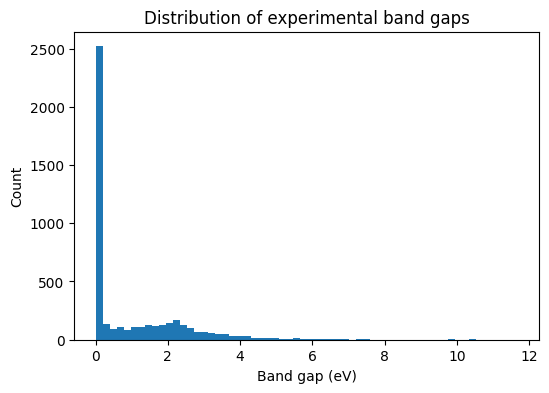

Fraction of Eg=0 entries: 0.532


In [6]:
task_name = "matbench_expt_gap"
df_raw = load_dataset(task_name)

print("Dataset:", task_name)
print("Shape:", df_raw.shape)
print(df_raw.head())

assert "composition" in df_raw.columns
assert "gap expt" in df_raw.columns

print(df_raw["gap expt"].describe())

plt.figure(figsize=(6,4))
plt.hist(df_raw["gap expt"], bins=60)
plt.xlabel("Band gap (eV)")
plt.ylabel("Count")
plt.title("Distribution of experimental band gaps")
plt.show()

zero_frac = (df_raw["gap expt"] == 0).mean()
print(f"Fraction of Eg=0 entries: {zero_frac:.3f}")



In [7]:
df = df_raw.copy()

df['composition_obj'] = df['composition'].apply(Composition)

featuriser = ElementProperty.from_preset("magpie")
featuriser.set_n_jobs(1)

df = featuriser.featurize_dataframe(df, col_id="composition_obj")

X = df.drop(columns=["composition", "gap expt", "composition_obj"])
y = df["gap expt"].values

print("Feature shape:", X.shape)


/usr/local/lib/python3.12/dist-packages/matminer/utils/data.py:326: UserWarning: MagpieData(impute_nan=False):
In a future release, impute_nan will be set to True by default.
                    This means that features that are missing or are NaNs for elements
                    from the data source will be replaced by the average of that value
                    over the available elements.
                    This avoids NaNs after featurization that are often replaced by
                    dataset-dependent averages.
  warnings.warn(f"{self.__class__.__name__}(impute_nan=False):\n" + IMPUTE_NAN_WARNING)


ElementProperty:   0%|          | 0/4604 [00:00<?, ?it/s]

Feature shape: (4604, 132)


Train, validate and test your model. Make sure to do proper data splits and to consider the hyperparamaters of your model.

<details>
<summary>Note on the ROC-AUC classification metric</summary>
There is one metric we didn't cover but is used in Matbench. In binary classification models, the ROC-AUC (Receiver Operating Characteristic - Area Under the Curve) score can be used to evaluate performance. It quantifies the ability of the model to distinguish between positive and negative instances across different decision thresholds. A higher ROC-AUC score (ranging from 0.5 to 1) indicates better performance, with 1 representing a perfect classifier and 0.5 indicating performance no better than random chance. There is a more detailed discussion here: https://developers.google.com/machine-learning/crash-course/classification/roc-and-auc.

The metric can be calculated using the `roc_auc_score` function from the `sklearn.metrics` module, e.g.

```python
from sklearn.metrics import roc_auc_score

# Assuming you have true labels (y_true) and predicted probabilities (y_pred_prob)
y_true = [...]  
y_pred_prob = [...]  

# Calculate ROC-AUC
roc_auc = roc_auc_score(y_true, y_pred_prob)

# Display the result
print(f'ROC-AUC Score: {roc_auc:.4f}')
```
</details>

In [8]:
# Split train and test dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape, X_test.shape)

#Define models
models = {
    "Dummy (mean)": DummyRegressor(strategy="mean"),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300,
        random_state=42
    ),

    "XGBoost": xgb.XGBRegressor(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        objective="reg:squarederror"
    ),
}


(3683, 132) (921, 132)


In [9]:
# 5-fold CV
def cv_report(model, Xtr, ytr, cv=5):
    rmse_scores = np.sqrt(
        -cross_val_score(model, Xtr, ytr, cv=cv,
                         scoring="neg_mean_squared_error")
    )

    mae_scores = -cross_val_score(
        model, Xtr, ytr, cv=cv,
        scoring="neg_mean_absolute_error"
    )

    return rmse_scores.mean(), rmse_scores.std(), mae_scores.mean(), mae_scores.std()


print("===== CV Results =====")

cv_results = []
for name, model in models.items():
    rmse_m, rmse_s, mae_m, mae_s = cv_report(model, X_train, y_train)

    print(f"{name:18s} | RMSE {rmse_m:.3f} ± {rmse_s:.3f}")

    cv_results.append([name, rmse_m, rmse_s, mae_m, mae_s])

cv_df = pd.DataFrame(
    cv_results,
    columns=["model","cv_rmse_mean","cv_rmse_std","cv_mae_mean","cv_mae_std"]
).sort_values("cv_rmse_mean")

print(cv_df)


===== CV Results =====
Dummy (mean)       | RMSE 1.439 ± 0.036
Random Forest      | RMSE 0.839 ± 0.038
Gradient Boosting  | RMSE 0.846 ± 0.030
XGBoost            | RMSE 0.813 ± 0.038
               model  cv_rmse_mean  cv_rmse_std  cv_mae_mean  cv_mae_std
3            XGBoost      0.812658     0.037837     0.462334    0.008039
1      Random Forest      0.839390     0.037887     0.465459    0.017372
2  Gradient Boosting      0.845783     0.030456     0.501584    0.009529
0       Dummy (mean)      1.439217     0.035505     1.136172    0.022453


## Model analysis and discussion

How well does your final model perform? Think of metrics and plots that are useful to dig a little deeper.

Compare against the best-performing model on the [MatBench](https://matbench.materialsproject.org) leaderboard.  With limited resources, don't expect to match this performance, but you should do better than a baseline model.

In [10]:
# Test set evaluation
def evaluate_on_test(model):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae  = mean_absolute_error(y_test, pred)
    r2   = r2_score(y_test, pred)

    return pred, rmse, mae, r2


test_results = []
pred_store = {}

for name, model in models.items():
    pred, rmse, mae, r2 = evaluate_on_test(model)

    pred_store[name] = pred
    test_results.append([name, rmse, mae, r2])

    print(f"{name:18s} | RMSE {rmse:.3f} | MAE {mae:.3f} | R2 {r2:.3f}")

test_df = pd.DataFrame(
    test_results,
    columns=["model","test_rmse","test_mae","test_r2"]
).sort_values("test_rmse")

print(test_df)


Dummy (mean)       | RMSE 1.467 | MAE 1.173 | R2 -0.000
Random Forest      | RMSE 0.839 | MAE 0.445 | R2 0.673
Gradient Boosting  | RMSE 0.865 | MAE 0.504 | R2 0.652
XGBoost            | RMSE 0.796 | MAE 0.453 | R2 0.706
               model  test_rmse  test_mae   test_r2
3            XGBoost   0.795547  0.452545  0.705732
1      Random Forest   0.838555  0.444784  0.673056
2  Gradient Boosting   0.864575  0.504176  0.652451
0       Dummy (mean)   1.466547  1.173240 -0.000006


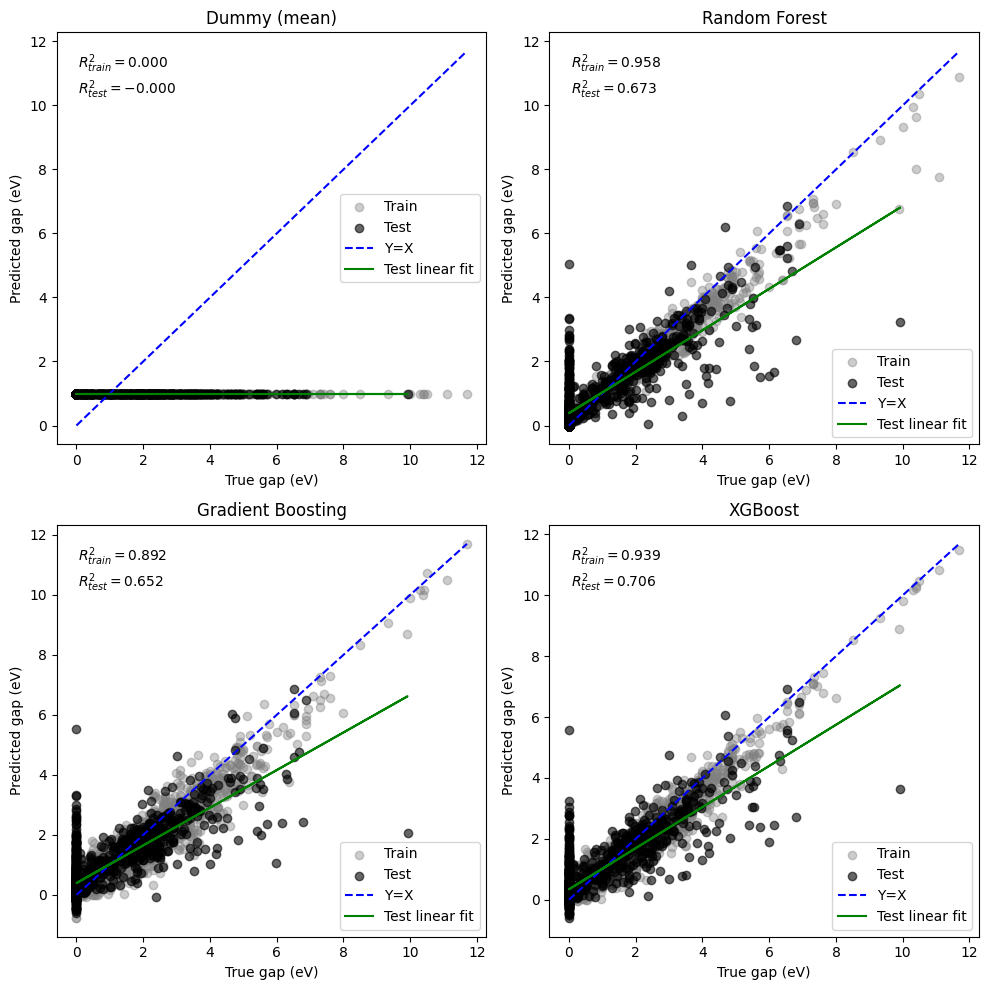

In [14]:
# Multi-model parity plots (ALL models)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

n_models = len(models)
cols = 2
rows = int(np.ceil(n_models / cols))

fig, axes = plt.subplots(rows, cols, figsize=(10, 5*rows))
axes = axes.flatten()

for ax, (name, model) in zip(axes, models.items()):

    # Train prediction
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)

    # Test prediction
    y_test_pred = model.predict(X_test)

    # Scatter
    ax.scatter(y_train, y_train_pred, color='gray', alpha=0.4, label="Train")
    ax.scatter(y_test, y_test_pred, color='black', alpha=0.6, label="Test")

    # Ideal line
    lims = [0, max(y.max(), y_test_pred.max())]
    ax.plot(lims, lims, 'b--', label="Y=X")

    # Linear fit (test)
    coef = np.polyfit(y_test, y_test_pred, 1)
    fit = np.poly1d(coef)
    ax.plot(y_test, fit(y_test), 'g-', label="Test linear fit")

    # R2
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)

    ax.text(
        0.05, 0.85,
        f"$R^2_{{train}}={r2_train:.3f}$\n$R^2_{{test}}={r2_test:.3f}$",
        transform=ax.transAxes
    )

    ax.set_title(name)
    ax.set_xlabel("True gap (eV)")
    ax.set_ylabel("Predicted gap (eV)")
    ax.legend()

plt.tight_layout()
plt.show()


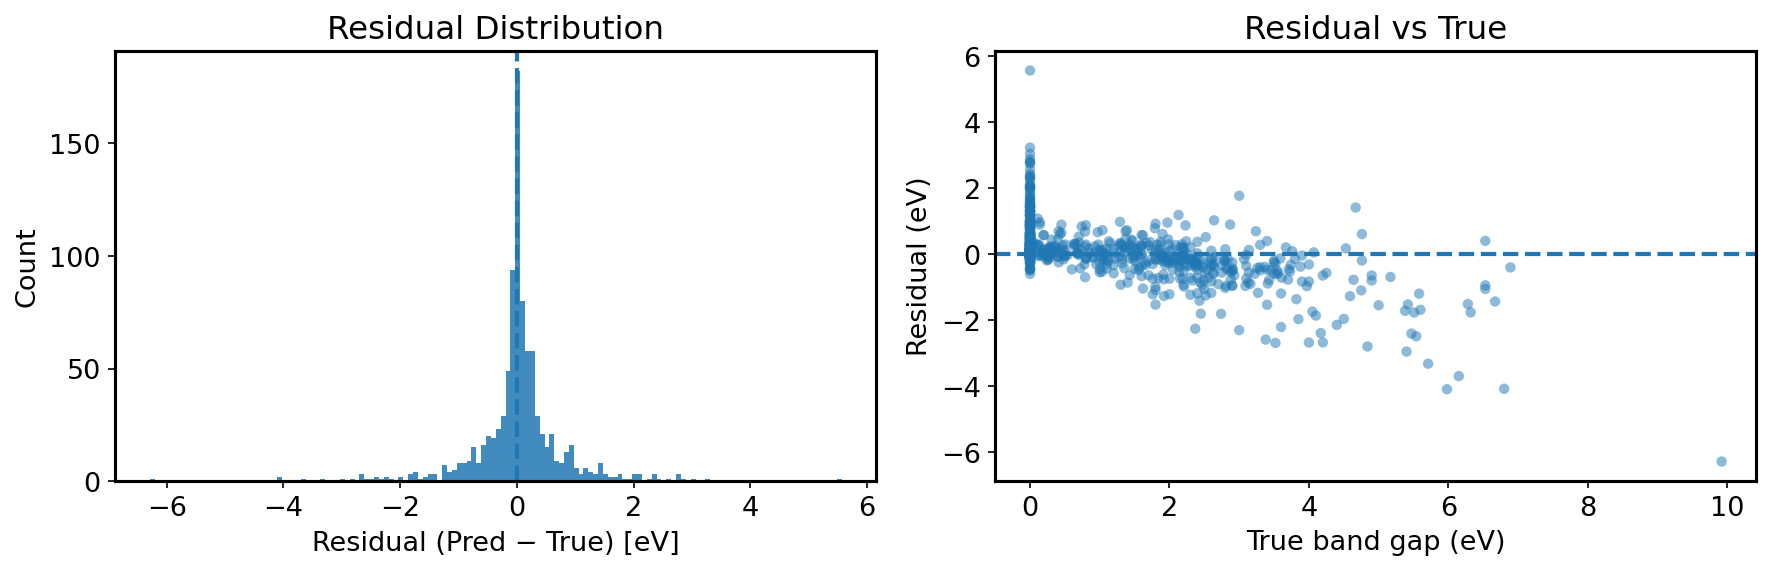

In [16]:
import matplotlib.pyplot as plt
import numpy as np

residuals = best_pred - y_test

plt.rcParams.update({
    "font.size": 13,
    "axes.linewidth": 1.5,
    "figure.dpi": 150
})

fig, ax = plt.subplots(1, 2, figsize=(12,4))

# ===== Residual histogram =====
ax[0].hist(residuals, bins="auto", alpha=0.85)
ax[0].axvline(0, linestyle="--", linewidth=2)
ax[0].set_xlabel("Residual (Pred − True) [eV]")
ax[0].set_ylabel("Count")
ax[0].set_title("Residual Distribution")

# ===== Residual vs actual =====
ax[1].scatter(
    y_test, residuals,
    alpha=0.5,
    s=25,
    edgecolors="none"
)

ax[1].axhline(0, linestyle="--", linewidth=2)
ax[1].set_xlabel("True band gap (eV)")
ax[1].set_ylabel("Residual (eV)")
ax[1].set_title("Residual vs True")

plt.tight_layout()
plt.show()


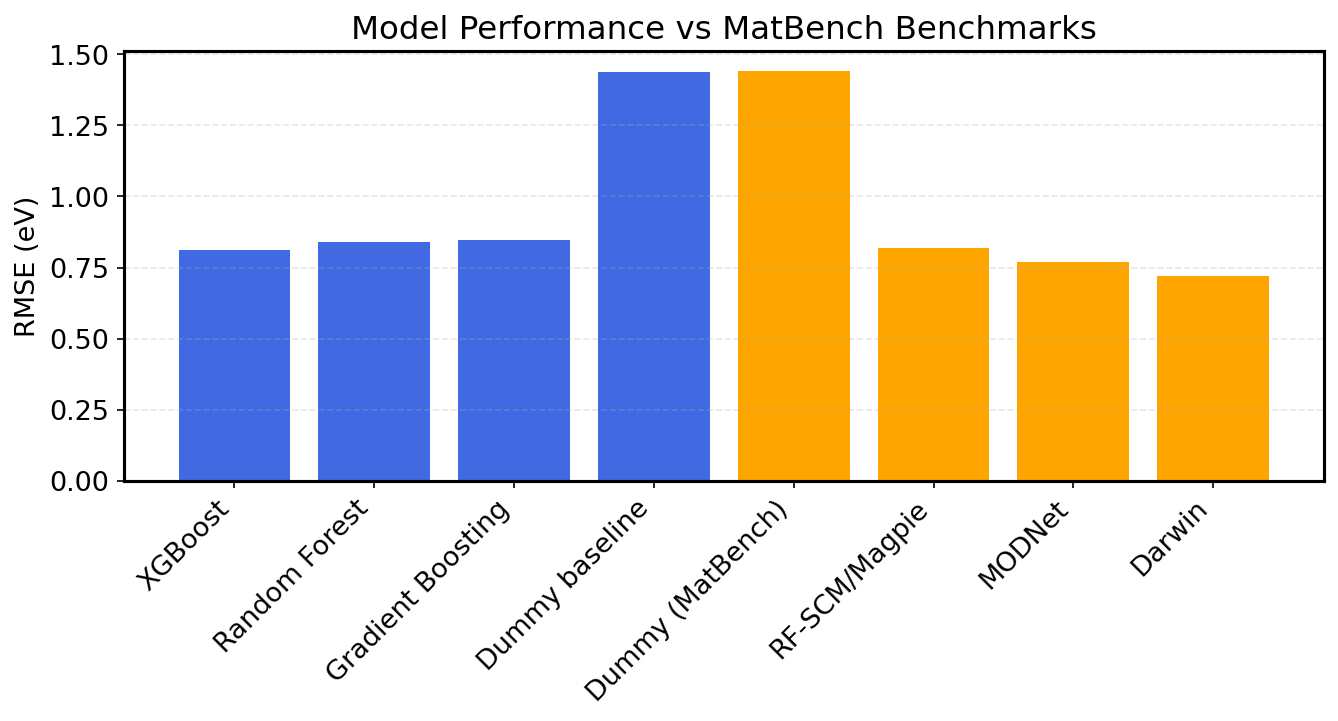

In [18]:
# Bar chart for comparison with benchmark
import matplotlib.pyplot as plt
import pandas as pd

your_results = cv_df.set_index("model")["cv_rmse_mean"]

your_results.index = your_results.index.str.replace(
    "Dummy (mean)", "Dummy baseline"
)


benchmark_results = pd.Series({
    "Dummy (MatBench)": 1.44,
    "RF-SCM/Magpie": 0.82,
    "MODNet": 0.77,
    "Darwin": 0.72
})


all_results = pd.concat([your_results, benchmark_results])

colors = ["royalblue"]*len(your_results) + ["orange"]*len(benchmark_results)

plt.figure(figsize=(9,5))

plt.bar(all_results.index, all_results.values, color=colors)

plt.ylabel("RMSE (eV)")
plt.title("Model Performance vs MatBench Benchmarks")

plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()


## Large Language Model (LLM) usage declaration

Acknowledge use of a generative model during your assignment. Points to consider:

* State which LLM (e.g. GPT-4, Gemini, Co-Pilot)

* Specify tasks (e.g. summarising research or code snippets)

* Were any limitations/biases noted?

* How did you ensure ethical use?

In [ ]:
# Spare cell




## ☘️ Final word

Good luck building your own model! We hope that you enjoyed the course and exercises. Dive deeper into the aspects that caught your interest. A useful starting point may be the [Resources](https://aronwalsh.github.io/MLforMaterials/Resources.html) page.

Remember that submission is on Blackboard and you should upload both the completed Juypter Notebook (`.ipynb` file), as well as your recorded narrated presentation (maximum 5 minutes; see guides on using [Zoom](https://www.youtube.com/watch?v=H9qhoAIzW3E) or [Powerpoint](https://www.youtube.com/watch?v=Y5dgwwa5XRA) for this purpose).